band_data_y_E0.000_size100_nk25.dat  loaded
band_data_y_E1.071_size100_nk25.dat  loaded
band_data_y_E2.143_size100_nk25.dat  loaded
band_data_y_E3.214_size100_nk25.dat  loaded
band_data_y_E4.286_size100_nk25.dat  loaded
band_data_y_E5.357_size100_nk25.dat  loaded
band_data_y_E6.429_size100_nk25.dat  loaded
band_data_y_E7.500_size100_nk25.dat  loaded
band_data_y_E8.571_size100_nk25.dat  loaded
band_data_y_E9.643_size100_nk25.dat  loaded
band_data_y_E10.714_size100_nk25.dat  loaded
band_data_y_E11.786_size100_nk25.dat  loaded
band_data_y_E12.857_size100_nk25.dat  loaded
band_data_y_E13.929_size100_nk25.dat  loaded
band_data_y_E15.000_size100_nk25.dat  loaded
gap_variation_y_field.dat saved.


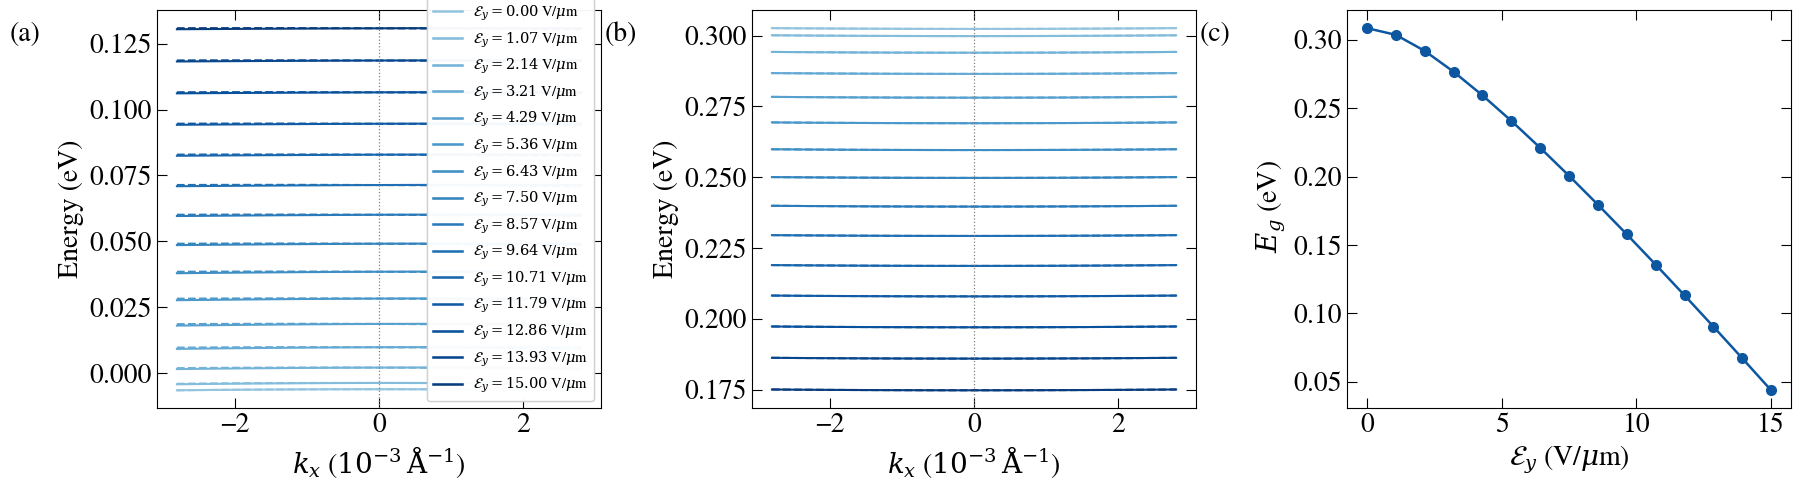

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ==============================================================
#                      GLOBAL SETTINGS
# ============================================================== 

plt.rcParams.update({
    "font.family": "Serif",
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 0.8
})

# ==============================================================
#                         PARAMETERS
# ============================================================== 

N = 100
Ny = Nz = N
NN = Ny * Nz
Nband = 10
nk = 25

# Electric fields in V/micrometre, as used in the filenames.

# electric_fields_set_1 = np.linspace(0e-4, 10.0e-4, 10)
# electric_fields_set_2 = np.linspace(11.1e-4, 15.5e-4, 5)
# electric_fields_set_3 = np.linspace(6e-4, 10.0e-4, 5)
# electric_fields = np.concatenate((electric_fields_set_1, electric_fields_set_2))

# # delete duplicate data from electric_fields
# electric_fields = np.unique(electric_fields)

electric_fields = np.linspace(0e-4, 15.0e-4, 15)
# electric_fields = electric_fields[14:]

# electric_fields = np.array([
#    0.0,
#    0.3e-5,
#    0.6e-5,
#     0.9e-5,
# ])
# Generate one blue shade automatically for every electric field.
# This continues to work if electric_fields contains 6, 10, or more values.
blue_cmap = plt.get_cmap("Blues")
colors = blue_cmap(
    np.linspace(
        0.40,
        0.95,
        len(electric_fields)
    )
)



# ==============================================================
#                         LOAD DATA
#
# Column 0: kx in Angstrom^{-1}
# Column 1: first valence-band energy in eV
# Column 2: second valence-band energy in eV
# Column 3: first conduction-band energy in eV
# Column 4: second conduction-band energy in eV
# Column 5: direct band gap at each kx in eV
# ============================================================== 

band_data = {}

for electric_field in electric_fields:

    filename = (
        f"band_data_y_E{electric_field*1e4:.3f}"
        f"_size{N}_nk{nk}.dat"
    )


    # print(f"Loading {filename} ...")

    data = np.loadtxt(
        filename,
        comments="#"
    )
    print(filename, " loaded")
    
    if data.ndim == 1:
        data = data[np.newaxis, :]

    if data.shape[1] < 6:
        raise ValueError(
            f"{filename} must contain six columns: "
            "kx, valence1, valence2, "
            "conduction1, conduction2, band_gap"
        )

    band_data[electric_field] = data




# Calculate the fundamental gap using the full sampled kx range.
# Both Kramers partners are included, so the valence-band maximum
# is allowed to shift away from the Gamma point under Rashba splitting.
gap_electric_field = np.sort(electric_fields)
fundamental_gap = np.empty(
    len(gap_electric_field),
    dtype=float
)

for index, electric_field in enumerate(gap_electric_field):

    data = band_data[electric_field]

    valence_band_maximum = np.max(
        data[:, 1:3]
    )

    conduction_band_minimum = np.min(
        data[:, 3:5]
    )

    fundamental_gap[index] = (
        conduction_band_minimum
        - valence_band_maximum
    )


def connect_kramers_partners(kx, lower_energy, upper_energy):
    """
    Connect a time-reversal-related pair across kx = 0.

    The input columns are energy ordered at every kx. Therefore,
    the physical branch identity must be exchanged across kx = 0.
    """

    negative_k = kx < 0.0
    zero_k = np.isclose(kx, 0.0, atol=1e-12)

    branch1 = np.where(
        negative_k,
        lower_energy,
        upper_energy
    )

    branch2 = np.where(
        negative_k,
        upper_energy,
        lower_energy
    )

    # Enforce their Kramers-degenerate meeting point at kx = 0.
    zero_energy = 0.5 * (
        lower_energy + upper_energy
    )

    branch1[zero_k] = zero_energy[zero_k]
    branch2[zero_k] = zero_energy[zero_k]

    return branch1, branch2

# ==============================================================
#                         PLOTTING
# ============================================================== 

fig, axs = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

field_handles = []

for electric_field, color in zip(electric_fields, colors):

    data = band_data[electric_field]

    kx = data[:, 0] * 1000
    valence1 = data[:, 1]
    valence2 = data[:, 2]
    conduction1 = data[:, 3]
    conduction2 = data[:, 4]

    valence_branch1, valence_branch2 = connect_kramers_partners(
        kx,
        valence1,
        valence2
    )

    conduction_branch1, conduction_branch2 = connect_kramers_partners(
        kx,
        conduction1,
        conduction2
    )

    field_label = (
        rf"$\mathcal{{E}}_y={electric_field*1e4:.2f}$ V/$\mu$m"
    )

    field_handles.append(
        Line2D(
            [0],
            [0],
            color=color,
            linewidth=1.8,
            # marker="o",
            markersize=4,
            label=field_label
        )
    )

    # Panel (a): valence-band evolution.
    axs[0].plot(
        kx,
        valence_branch1,
        color=color,
        linestyle="-",
        # marker="o",
        markersize=3.5,
        linewidth=1.5
    )

    axs[0].plot(
        kx,
        valence_branch2,
        color=color,
        linestyle="--",
        # marker="s",
        markersize=3.5,
        linewidth=1.5
    )

    # Panel (b): conduction-band evolution.
    axs[1].plot(
        kx,
        conduction_branch1,
        color=color,
        linestyle="-",
        # marker="o",
        markersize=3.5,
        linewidth=1.5
    )

    axs[1].plot(
        kx,
        conduction_branch2,
        color=color,
        linestyle="--",
        # marker="s",
        markersize=3.5,
        linewidth=1.5
    )

# Panel (c): fundamental gap versus electric field.
axs[2].plot(
    gap_electric_field*1e4,
    fundamental_gap,
    color=blue_cmap(0.85),
    linestyle="-",
    marker="o",
    markersize=7,
    linewidth=1.8
)
gap_data = np.vstack([gap_electric_field*1e4, fundamental_gap])
np.savetxt("gap_variation_y_field.dat",gap_data)
print("gap_variation_y_field.dat saved.")

# ==============================================================
#                     AXIS FORMATTING
# ============================================================== 

# axs[0].set_title(
#     "Valence-band evolution",
#     fontsize=15
# )

# axs[1].set_title(
#     "Conduction-band evolution",
#     fontsize=15
# )

# axs[2].set_title(
#     "Fundamental band gap",
#     fontsize=15
# )

for ax in axs[:2]:

    ax.axvline(
        x=0.0,
        color="gray",
        linestyle=":",
        linewidth=0.9
    )

    ax.set_xlabel(
        r"$k_x$ ($10^{-3}\,\mathrm{\AA}^{-1}$)",
        fontsize=20
    )

    ax.set_ylabel(
        r"Energy (eV)",
        fontsize=20
    )

    # ax.set_xlim(-2,2)
    # ax.set_ylim(-0.00625,-0.006)

axs[2].set_xlabel(
    r"$\mathcal{E}_y$ (V/$\mu$m)",
    fontsize=20
)

axs[2].set_ylabel(
    r" $E_g$ (eV)",
    fontsize=20
)

for ax in axs:

    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        length=7,
        width=0.8,
        labelsize=20
    )

    # ax.tick_params(
    #     axis="both",
    #     which="minor",
    #     direction="in",
    #     length=3,
    #     width=0.8
    # )

    # ax.minorticks_on()

# Keep the electric-field legend only in panel (a).
field_legend = axs[0].legend(
    handles=field_handles,
    fontsize=10.5,
    frameon=True,
    loc="lower right"
)
axs[0].add_artist(field_legend)

# Line-style legends identify the two band branches.
valence_handles = [
    Line2D([0], [0], color="gray", linestyle="-", label=r"$E_{v,1}$"),
    Line2D([0], [0], color="gray", linestyle="--", label=r"$E_{v,2}$")
]

# axs[0].legend(
#     handles=valence_handles,
#     fontsize=10.5,
#     frameon=True,
#     loc="lower right"
# )

# Panel labels.
for ax, panel_label in zip(axs, ["(a)", "(b)", "(c)"]):
    ax.text(
        -0.33,
        0.97,
        panel_label,
        transform=ax.transAxes,
        fontsize=20,
        # fontweight="bold",
        va="top"
    )

plt.tight_layout()

plt.savefig(
    f"band_evolution_vs_Ey_size{N}_nk{nk}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    f"band_evolution_vs_Ey_size{N}_nk{nk}.svg",
    bbox_inches="tight"
)

plt.show()

In [3]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D

# # ==============================================================
# #                      GLOBAL SETTINGS
# # ==============================================================

# plt.rcParams.update({
#     "font.family": "Serif",
#     "mathtext.fontset": "dejavuserif",
#     "axes.linewidth": 0.8
# })

# # ==============================================================
# #                         PARAMETERS
# # ==============================================================

# N = 100
# Ny = Nz = N
# Nband = 10
# nk = 25

# # Electric fields in V/micrometre, as used in the filenames.
# electric_fields = np.linspace(0.0, 15.0e-4, 15)
# electric_fields = electric_fields[::3]
# # Generate one blue shade for each electric field.
# blue_cmap = plt.get_cmap("Blues")

# colors = blue_cmap(
#     np.linspace(
#         0.40,
#         0.95,
#         len(electric_fields)
#     )
# )

# # ==============================================================
# #                         LOAD DATA
# #
# # Column 0: kx in Angstrom^{-1}
# # Column 1: first valence-band energy in eV
# # Column 2: second valence-band energy in eV
# # Column 3: first conduction-band energy in eV
# # Column 4: second conduction-band energy in eV
# # Column 5: direct band gap at each kx in eV
# # ==============================================================

# band_data = {}

# for electric_field in electric_fields:

#     filename = (
#         f"band_data_y_E{electric_field * 1e4:.3f}"
#         f"_size{N}_nk{nk}.dat"
#     )

#     data = np.loadtxt(
#         filename,
#         comments="#"
#     )

#     if data.ndim == 1:
#         data = data[np.newaxis, :]

#     if data.shape[1] < 6:
#         raise ValueError(
#             f"{filename} must contain six columns: "
#             "kx, valence1, valence2, "
#             "conduction1, conduction2, band_gap"
#         )

#     band_data[electric_field] = data


# # ==============================================================
# #                CONNECT THE KRAMERS PARTNERS
# # ==============================================================

# def connect_kramers_partners(kx, lower_energy, upper_energy):
#     """
#     Connect a time-reversal-related pair across kx = 0.

#     Since the input columns are energy ordered at each kx,
#     the physical branch identities must be exchanged across kx = 0.
#     """

#     negative_k = kx < 0.0
#     zero_k = np.isclose(kx, 0.0, atol=1e-12)

#     branch1 = np.where(
#         negative_k,
#         lower_energy,
#         upper_energy
#     )

#     branch2 = np.where(
#         negative_k,
#         upper_energy,
#         lower_energy
#     )

#     # Enforce Kramers degeneracy at kx = 0.
#     zero_energy = 0.5 * (
#         lower_energy + upper_energy
#     )

#     branch1[zero_k] = zero_energy[zero_k]
#     branch2[zero_k] = zero_energy[zero_k]

#     return branch1, branch2


# # ==============================================================
# #                         PLOTTING
# # ==============================================================

# fig, ax = plt.subplots(
#     figsize=(3, 6)
# )

# field_handles = []

# for electric_field, color in zip(electric_fields, colors):

#     data = band_data[electric_field]

#     # Convert kx to units of 10^{-3} Angstrom^{-1}.
#     kx = data[:, 0] * 1000

#     valence1 = data[:, 1]
#     valence2 = data[:, 2]

#     conduction1 = data[:, 3]
#     conduction2 = data[:, 4]

#     valence_branch1, valence_branch2 = connect_kramers_partners(
#         kx,
#         valence1,
#         valence2
#     )

#     conduction_branch1, conduction_branch2 = connect_kramers_partners(
#         kx,
#         conduction1,
#         conduction2
#     )

#     field_label = (
#         rf"$\mathcal{{E}}_y={electric_field * 1e4:.2f}$ V/$\mu$m"
#     )

#     field_handles.append(
#         Line2D(
#             [0],
#             [0],
#             color=color,
#             linewidth=1.8,
#             label=field_label
#         )
#     )

#     # ---------------- Valence bands ----------------

#     ax.plot(
#         kx,
#         valence_branch1,
#         color=color,
#         linestyle="-",
#         linewidth=1.5
#     )

#     ax.plot(
#         kx,
#         valence_branch2,
#         color=color,
#         linestyle="--",
#         linewidth=1.5
#     )

#     # ---------------- Conduction bands ----------------

#     ax.plot(
#         kx,
#         conduction_branch1,
#         color=color,
#         linestyle="-",
#         linewidth=1.5
#     )

#     ax.plot(
#         kx,
#         conduction_branch2,
#         color=color,
#         linestyle="--",
#         linewidth=1.5
#     )


# # ==============================================================
# #                     AXIS FORMATTING
# # ==============================================================

# ax.axvline(
#     x=0.0,
#     color="gray",
#     linestyle=":",
#     linewidth=0.9
# )

# ax.set_xlabel(
#     r"$k_x$ ($10^{-3}\,\mathrm{\AA}^{-1}$)",
#     fontsize=20
# )

# ax.set_ylabel(
#     r"Energy (eV)",
#     fontsize=20
# )

# ax.tick_params(
#     axis="both",
#     which="major",
#     direction="in",
#     length=7,
#     width=0.8,
#     labelsize=18
# )

# # Optional limits:
# # ax.set_xlim(-2, 2)
# # ax.set_ylim(-0.02, 0.35)


# # ==============================================================
# #                          LEGENDS
# # ==============================================================

# # Electric-field legend.
# field_legend = ax.legend(
#     handles=field_handles,
#     fontsize=9.5,
#     frameon=True,
#     loc="center left",
#     bbox_to_anchor=(1.02, 0.5)
# )

# ax.add_artist(field_legend)

# # # Solid and dashed lines indicate the two Kramers-connected branches.
# # branch_handles = [
# #     Line2D(
# #         [0],
# #         [0],
# #         color="gray",
# #         linestyle="-",
# #         linewidth=1.5,
# #         label="Branch 1"
# #     ),
# #     Line2D(
# #         [0],
# #         [0],
# #         color="gray",
# #         linestyle="--",
# #         linewidth=1.5,
# #         label="Branch 2"
# #     )
# # ]

# # ax.legend(
# #     handles=branch_handles,
# #     fontsize=11,
# #     frameon=True,
# #     loc="center right"
# # )

# plt.tight_layout()

# # ==============================================================
# #                         SAVE FIGURE
# # ==============================================================

# plt.savefig(
#     f"conduction_valence_bands_vs_Ey_size{N}_nk{nk}.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# plt.savefig(
#     f"conduction_valence_bands_vs_Ey_size{N}_nk{nk}.svg",
#     bbox_inches="tight"
# )

# plt.show()

band_data_z_E0.000_size100_nk25.dat  loaded
band_data_z_E1.071_size100_nk25.dat  loaded
band_data_z_E2.143_size100_nk25.dat  loaded
band_data_z_E3.214_size100_nk25.dat  loaded
band_data_z_E4.286_size100_nk25.dat  loaded
band_data_z_E5.357_size100_nk25.dat  loaded
band_data_z_E6.429_size100_nk25.dat  loaded
band_data_z_E7.500_size100_nk25.dat  loaded
band_data_z_E8.571_size100_nk25.dat  loaded
band_data_z_E9.643_size100_nk25.dat  loaded
band_data_z_E10.714_size100_nk25.dat  loaded
band_data_z_E11.786_size100_nk25.dat  loaded
gap_variation_z_field.dat saved


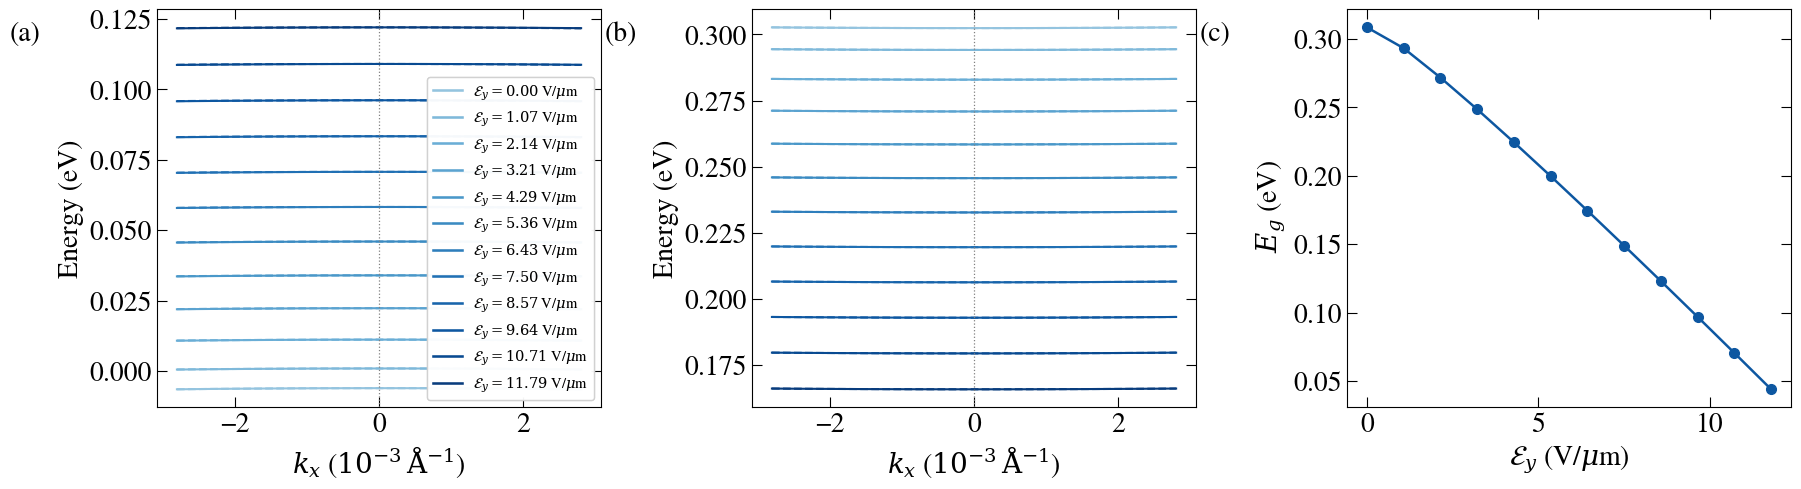

In [4]:
# z-directional field


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ==============================================================
#                      GLOBAL SETTINGS
# ============================================================== 

plt.rcParams.update({
    "font.family": "Serif",
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 0.8
})

# ==============================================================
#                         PARAMETERS
# ============================================================== 

N = 100
Ny = Nz = N
NN = Ny * Nz
Nband = 10
nk = 25

# Electric fields in V/micrometre, as used in the filenames.

# electric_fields_set_1 = np.linspace(0e-4, 10.0e-4, 10)
# electric_fields_set_2 = np.linspace(11.1e-4, 15.5e-4, 5)
# electric_fields_set_3 = np.linspace(6e-4, 10.0e-4, 5)
# electric_fields = np.concatenate((electric_fields_set_1, electric_fields_set_2))

# # delete duplicate data from electric_fields
# electric_fields = np.unique(electric_fields)

electric_fields = np.linspace(0e-4, 15.0e-4, 15)
electric_fields = electric_fields[:12]

# electric_fields = np.array([
#    0.0,
#    0.3e-5,
#    0.6e-5,
#     0.9e-5,
# ])
# Generate one blue shade automatically for every electric field.
# This continues to work if electric_fields contains 6, 10, or more values.
blue_cmap = plt.get_cmap("Blues")
colors = blue_cmap(
    np.linspace(
        0.40,
        0.95,
        len(electric_fields)
    )
)



# ==============================================================
#                         LOAD DATA
#
# Column 0: kx in Angstrom^{-1}
# Column 1: first valence-band energy in eV
# Column 2: second valence-band energy in eV
# Column 3: first conduction-band energy in eV
# Column 4: second conduction-band energy in eV
# Column 5: direct band gap at each kx in eV
# ============================================================== 

band_data = {}

for electric_field in electric_fields:

    filename = (
        f"band_data_z_E{electric_field*1e4:.3f}"
        f"_size{N}_nk{nk}.dat"
    )

    # print(f"Loading {filename} ...")

    data = np.loadtxt(
        filename,
        comments="#"
    )

    print(filename, " loaded")
    if data.ndim == 1:
        data = data[np.newaxis, :]

    if data.shape[1] < 6:
        raise ValueError(
            f"{filename} must contain six columns: "
            "kx, valence1, valence2, "
            "conduction1, conduction2, band_gap"
        )

    band_data[electric_field] = data




# Calculate the fundamental gap using the full sampled kx range.
# Both Kramers partners are included, so the valence-band maximum
# is allowed to shift away from the Gamma point under Rashba splitting.
gap_electric_field = np.sort(electric_fields)
fundamental_gap = np.empty(
    len(gap_electric_field),
    dtype=float
)

for index, electric_field in enumerate(gap_electric_field):

    data = band_data[electric_field]

    valence_band_maximum = np.max(
        data[:, 1:3]
    )

    conduction_band_minimum = np.min(
        data[:, 3:5]
    )

    fundamental_gap[index] = (
        conduction_band_minimum
        - valence_band_maximum
    )


def connect_kramers_partners(kx, lower_energy, upper_energy):
    """
    Connect a time-reversal-related pair across kx = 0.

    The input columns are energy ordered at every kx. Therefore,
    the physical branch identity must be exchanged across kx = 0.
    """

    negative_k = kx < 0.0
    zero_k = np.isclose(kx, 0.0, atol=1e-12)

    branch1 = np.where(
        negative_k,
        lower_energy,
        upper_energy
    )

    branch2 = np.where(
        negative_k,
        upper_energy,
        lower_energy
    )

    # Enforce their Kramers-degenerate meeting point at kx = 0.
    zero_energy = 0.5 * (
        lower_energy + upper_energy
    )

    branch1[zero_k] = zero_energy[zero_k]
    branch2[zero_k] = zero_energy[zero_k]

    return branch1, branch2

# ==============================================================
#                         PLOTTING
# ============================================================== 

fig, axs = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

field_handles = []

for electric_field, color in zip(electric_fields, colors):

    data = band_data[electric_field]

    kx = data[:, 0] * 1000
    valence1 = data[:, 1]
    valence2 = data[:, 2]
    conduction1 = data[:, 3]
    conduction2 = data[:, 4]

    valence_branch1, valence_branch2 = connect_kramers_partners(
        kx,
        valence1,
        valence2
    )

    conduction_branch1, conduction_branch2 = connect_kramers_partners(
        kx,
        conduction1,
        conduction2
    )

    field_label = (
        rf"$\mathcal{{E}}_y={electric_field*1e4:.2f}$ V/$\mu$m"
    )

    field_handles.append(
        Line2D(
            [0],
            [0],
            color=color,
            linewidth=1.8,
            # marker="o",
            markersize=4,
            label=field_label
        )
    )

    # Panel (a): valence-band evolution.
    axs[0].plot(
        kx,
        valence_branch1,
        color=color,
        linestyle="-",
        # marker="o",
        markersize=3.5,
        linewidth=1.5
    )

    axs[0].plot(
        kx,
        valence_branch2,
        color=color,
        linestyle="--",
        # marker="s",
        markersize=3.5,
        linewidth=1.5
    )

    # Panel (b): conduction-band evolution.
    axs[1].plot(
        kx,
        conduction_branch1,
        color=color,
        linestyle="-",
        # marker="o",
        markersize=3.5,
        linewidth=1.5
    )

    axs[1].plot(
        kx,
        conduction_branch2,
        color=color,
        linestyle="--",
        # marker="s",
        markersize=3.5,
        linewidth=1.5
    )

# Panel (c): fundamental gap versus electric field.
axs[2].plot(
    gap_electric_field*1e4,
    fundamental_gap,
    color=blue_cmap(0.85),
    linestyle="-",
    marker="o",
    markersize=7,
    linewidth=1.8
)

gap_data = np.vstack([gap_electric_field*1e4, fundamental_gap])
np.savetxt("gap_variation_z_field.dat",gap_data)
print("gap_variation_z_field.dat saved")

# ==============================================================
#                     AXIS FORMATTING
# ============================================================== 

# axs[0].set_title(
#     "Valence-band evolution",
#     fontsize=15
# )

# axs[1].set_title(
#     "Conduction-band evolution",
#     fontsize=15
# )

# axs[2].set_title(
#     "Fundamental band gap",
#     fontsize=15
# )

for ax in axs[:2]:

    ax.axvline(
        x=0.0,
        color="gray",
        linestyle=":",
        linewidth=0.9
    )

    ax.set_xlabel(
        r"$k_x$ ($10^{-3}\,\mathrm{\AA}^{-1}$)",
        fontsize=20
    )

    ax.set_ylabel(
        r"Energy (eV)",
        fontsize=20
    )

    # ax.set_xlim(-2,2)
    # ax.set_ylim(-0.00625,-0.006)

axs[2].set_xlabel(
    r"$\mathcal{E}_y$ (V/$\mu$m)",
    fontsize=20
)

axs[2].set_ylabel(
    r" $E_g$ (eV)",
    fontsize=20
)

for ax in axs:

    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        length=7,
        width=0.8,
        labelsize=20
    )

    # ax.tick_params(
    #     axis="both",
    #     which="minor",
    #     direction="in",
    #     length=3,
    #     width=0.8
    # )

    # ax.minorticks_on()

# Keep the electric-field legend only in panel (a).
field_legend = axs[0].legend(
    handles=field_handles,
    fontsize=10.5,
    frameon=True,
    loc="lower right"
)
axs[0].add_artist(field_legend)

# Line-style legends identify the two band branches.
valence_handles = [
    Line2D([0], [0], color="gray", linestyle="-", label=r"$E_{v,1}$"),
    Line2D([0], [0], color="gray", linestyle="--", label=r"$E_{v,2}$")
]

# axs[0].legend(
#     handles=valence_handles,
#     fontsize=10.5,
#     frameon=True,
#     loc="lower right"
# )

# Panel labels.
for ax, panel_label in zip(axs, ["(a)", "(b)", "(c)"]):
    ax.text(
        -0.33,
        0.97,
        panel_label,
        transform=ax.transAxes,
        fontsize=20,
        # fontweight="bold",
        va="top"
    )

plt.tight_layout()

plt.savefig(
    f"band_evolution_vs_Ey_size{N}_nk{nk}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    f"band_evolution_vs_Ey_size{N}_nk{nk}.svg",
    bbox_inches="tight"
)

plt.show()

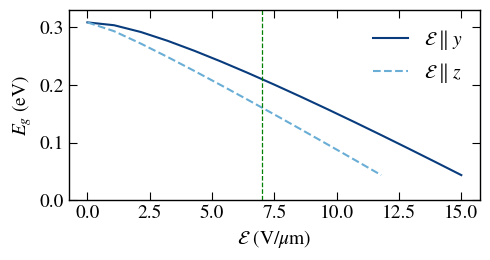

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ---- APS/PRB-style global rc settings ----
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "DejaVu Serif"],
    "mathtext.fontset": "stix",       # close to Computer Modern / matches serif body text
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
    "xtick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.major.size": 6,
    "ytick.minor.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "legend.frameon": False,
    "savefig.dpi": 300,
})

y_case = np.loadtxt("gap_variation_y_field.dat")
z_case = np.loadtxt("gap_variation_z_field.dat")

# APS single-column width is ~3.375 in; using slightly larger for a 2-panel-worthy plot
fig, ax = plt.subplots(figsize=(5, 2.7))

ax.plot(
    y_case[0],
    y_case[1],
    color=blue_cmap(0.95),
    linestyle="-",
    # marker="o",
    # markersize=5,
    # markerfacecolor=blue_cmap(0.85),
    # markeredgecolor="black",
    # markeredgewidth=0.5,
    linewidth=1.5,
    label=r"$\mathcal{E}$ || $y$",
)

ax.plot(
    z_case[0],
    z_case[1],
    color=blue_cmap(0.5),   # distinct shade so the two curves are distinguishable
    linestyle="dashed",
    # marker="s",
    # markersize=5,
    # markerfacecolor=blue_cmap(0.35),
    # markeredgecolor="black",
    # markeredgewidth=0.5,
    linewidth=1.5,
    label=r"$\mathcal{E}$ || $z$",
)

ax.set_xlabel(r"$\mathcal{E}$ (V/$\mu$m)", fontsize=14)
ax.set_ylabel(r"$E_g$ (eV)", fontsize=14)
ax.set_ylim(0, 0.33)
ax.tick_params(
    axis="both",
    which="major",
    direction="in",
    length=6,
    width=0.8,
    labelsize=14,
)
# ax.tick_params(
#     axis="both",
#     which="minor",
#     direction="in",
#     length=3,
#     width=0.6,
# )

ax.axvline(x = 7, color="green", linestyle="--", linewidth=0.9)
ax.legend(fontsize=14, loc="best", handlelength=1.8)

fig.tight_layout()
fig.savefig("gap_variation.pdf", bbox_inches="tight")
fig.savefig("gap_variation.svg", bbox_inches="tight")
plt.show()